# Mini Project 2
Nama: Faraday Barr Fatahillah

#### Background

Diabetes merupakan penyakit kronis yang terjadi saat pankreas tidak dapat membuat hormon Insulin. Jika dibiarkan, penyakit ini dapat menyebabkan buta, gagal ginjal, struk, dan lain lagi. Menurut World Health Organization (WHO), [mulai tahun 1990 hingga 2022 masyarakat yang memiliki diabetes naik hingga 630 juta orang](https://www.who.int/news-room/fact-sheets/detail/diabetes). Peningkatan ini menunjukkan bahwa diabetes merupakan tantangan kesehatan masyarakat yang sangat penting, sehingga diperlukan pendekatan berbasis data untuk membantu deteksi dini dan pengambilan keputusan medis. Oleh karena itu, pemanfaatan machine learning menjadi pendekatan yang berpotensi untuk membantu deteksi dini diabetes.

#### Problem Statements

1. Bisakah model machine learning mendeteksi seseorang memiliki diabetes berdasarkan data kesehatan?
2. Model machine learning mana yang dapat melakukan deteksi diabetes paling baik, dan bagaimana untuk di optimasi lebih lanjut?

#### Objective

Membuat dan membandingkan minimal dua model machine learning untuk mendeteksi diabetes

#### Dataset

Dataset menggunakan dataset publik yang tersedia di kaggle yang merupakan pengambilan data dari lembaga [The Center of Disease Control and Prevention (CDC)](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset). Dataset ini diambil setiap tahun dalam program The Behavioral Risk Factor Surveillance System (BFRSS) yang dilaksanakan dengan menelpon ke lebih dari 400,000 warga Amerika. Pertanyaan yang ditanyakan biasanya seputar perilaku yang beresiko kepada kesehatan, kondisi kesehatan kronis, dan pemanfaatan layanan pencegahan.
&nbsp;

Data yang tersedia pada dataset ini memiliki 22 fitur dengan sebagian besar dari fitur merupakan kategorik, seperti memiliki darah tinggi, pernah mengalami stroke, memiliki penyakit jantung, dan sebagainya. Melihat bentuk data seperti ini, beberapa metode yang dapat dilakukan untuk train model adalah melakukan encoding.
&nbsp;

Selain itu, dataset ini memiliki imbalance data pada yang diabetik dengan yang tidak diabetik sehingga perlu dilakukan SMOTE untuk membalance data diabetik.

#### Import Library

In [76]:
# All library needed

# Base ML Library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Smote
from imblearn.over_sampling import SMOTE

# Dataset Splitter
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Metrics and Reports
from sklearn.metrics import classification_report, recall_score

# Statistical Test
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from sklearn.utils import resample
from sklearn.model_selection import learning_curve

# Visualisasi
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#### Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('diabetes_bfrss.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# Cek informasi Dataset dari segi jumlah data, fitur, null-value, dan jenis data 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [5]:
# Cek data unik setiap tabel walaupun data merupakan bentuk float semua
rows = []

for col in df.columns:
    rows.append({
        "Column": col,
        "Unique Values": df[col].unique() # Gunakan looping dan method unique() untuk cek semua data di masukkan ke dalam list 
    })

unique_table = pd.DataFrame(rows) # Ubah list ke dataframe biar mudah untuk dilihat
unique_table


,Column,Unique Values
0,Diabetes_012,"[0.0, 2.0, 1.0]"
1,HighBP,"[1.0, 0.0]"
2,HighChol,"[1.0, 0.0]"
3,CholCheck,"[1.0, 0.0]"
4,BMI,"[40.0, 25.0, 28.0, 27.0, 24.0, 30.0, 34.0, 26...."
5,Smoker,"[1.0, 0.0]"
6,Stroke,"[0.0, 1.0]"
7,HeartDiseaseorAttack,"[0.0, 1.0]"
8,PhysActivity,"[0.0, 1.0]"
9,Fruits,"[0.0, 1.0]"


Melihat hasil data unik per fitur, dataset ini lebih banyak memiliki kolom kategorikal dari pada kolom numerikal. Hal ini perlu di sesuaikan dengan deskripsi dataset yang sudah diberikan. Berikut merupakan informasi yang didapatkan.

Label per Column:
1. 'Diabates_012': Target, 0 = no diabetes, 1 = prediabetes, 2 = diabetes
2. 'HighBP': Binary, 0 = no high, BP 1 = high BP
3. 'HighChol': Binary, 0 = no high cholesterol, 1 = high cholesterol
4. 'CholCheck': Binary, 0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years
5. 'BMI': Float
6. 'Smoker': Binary, 0 = no, 1 = yes
7. 'Stroke': Binary, 0 = no, 1 = yes
8. 'HeartDiseaseorAttack, Binary 0 = no, 1 = yes
9. 'PhysActivity': Binary, 0 = no, 1 = yes
10. 'Fruits': Binary, 0 = no, 1 = yes
11. 'Veggies': Binary, 0 = no, 1 = yes
12. 'HvyAlcoholConsump': Binary, 0 = no, 1 = yes
13. 'AnyHealthCare': Binary, 0 = no, 1 = yes
14. 'NoDocbcCost': Binary, 0 = no, 1 = yes
15. 'GenHlth': Categorical, 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor
16. 'MentHlth': Float, scale 1-30 days
17. 'PhysHlth': Float, scale 1-30 days
18. 'DiffWalk': Binary, 0 = no, 1 = yes
19. 'Sex': Binary, 0 = female, 1 = male
20. 'Age': Categorical, 1 = 18-24, 9 = 60-64, 13 = 80 or older
21. 'Education': Categorical, 1 = Never attended school or only kindergarten, 2 = Grades 1 through 8 (Elementary), 3 = Grades 9 through 11 (Some high school), 4 = Grade 12 or GED (High school graduate), 5 = College 1 year to 3 years (Some college or technical school), 6 = College 4 years or more (College graduate)
22. 'Income': Categorical, 1 = less than $10,000, 5 = less than $35,000, 8 = $75,000 or more


Dari deskripsi ini, data yang dapat dihitung sebagai kolom numerik yaitu BMI. Ada yang mungkin sedikit aneh di kolom ```MentHlth``` dan ```PhysHlth``` yang merupakan skala numerik, tetapi kelihatan cenderung lebih kategorik. Mungkin data ini akan dihilangkan atau dilakukan feature engineering.

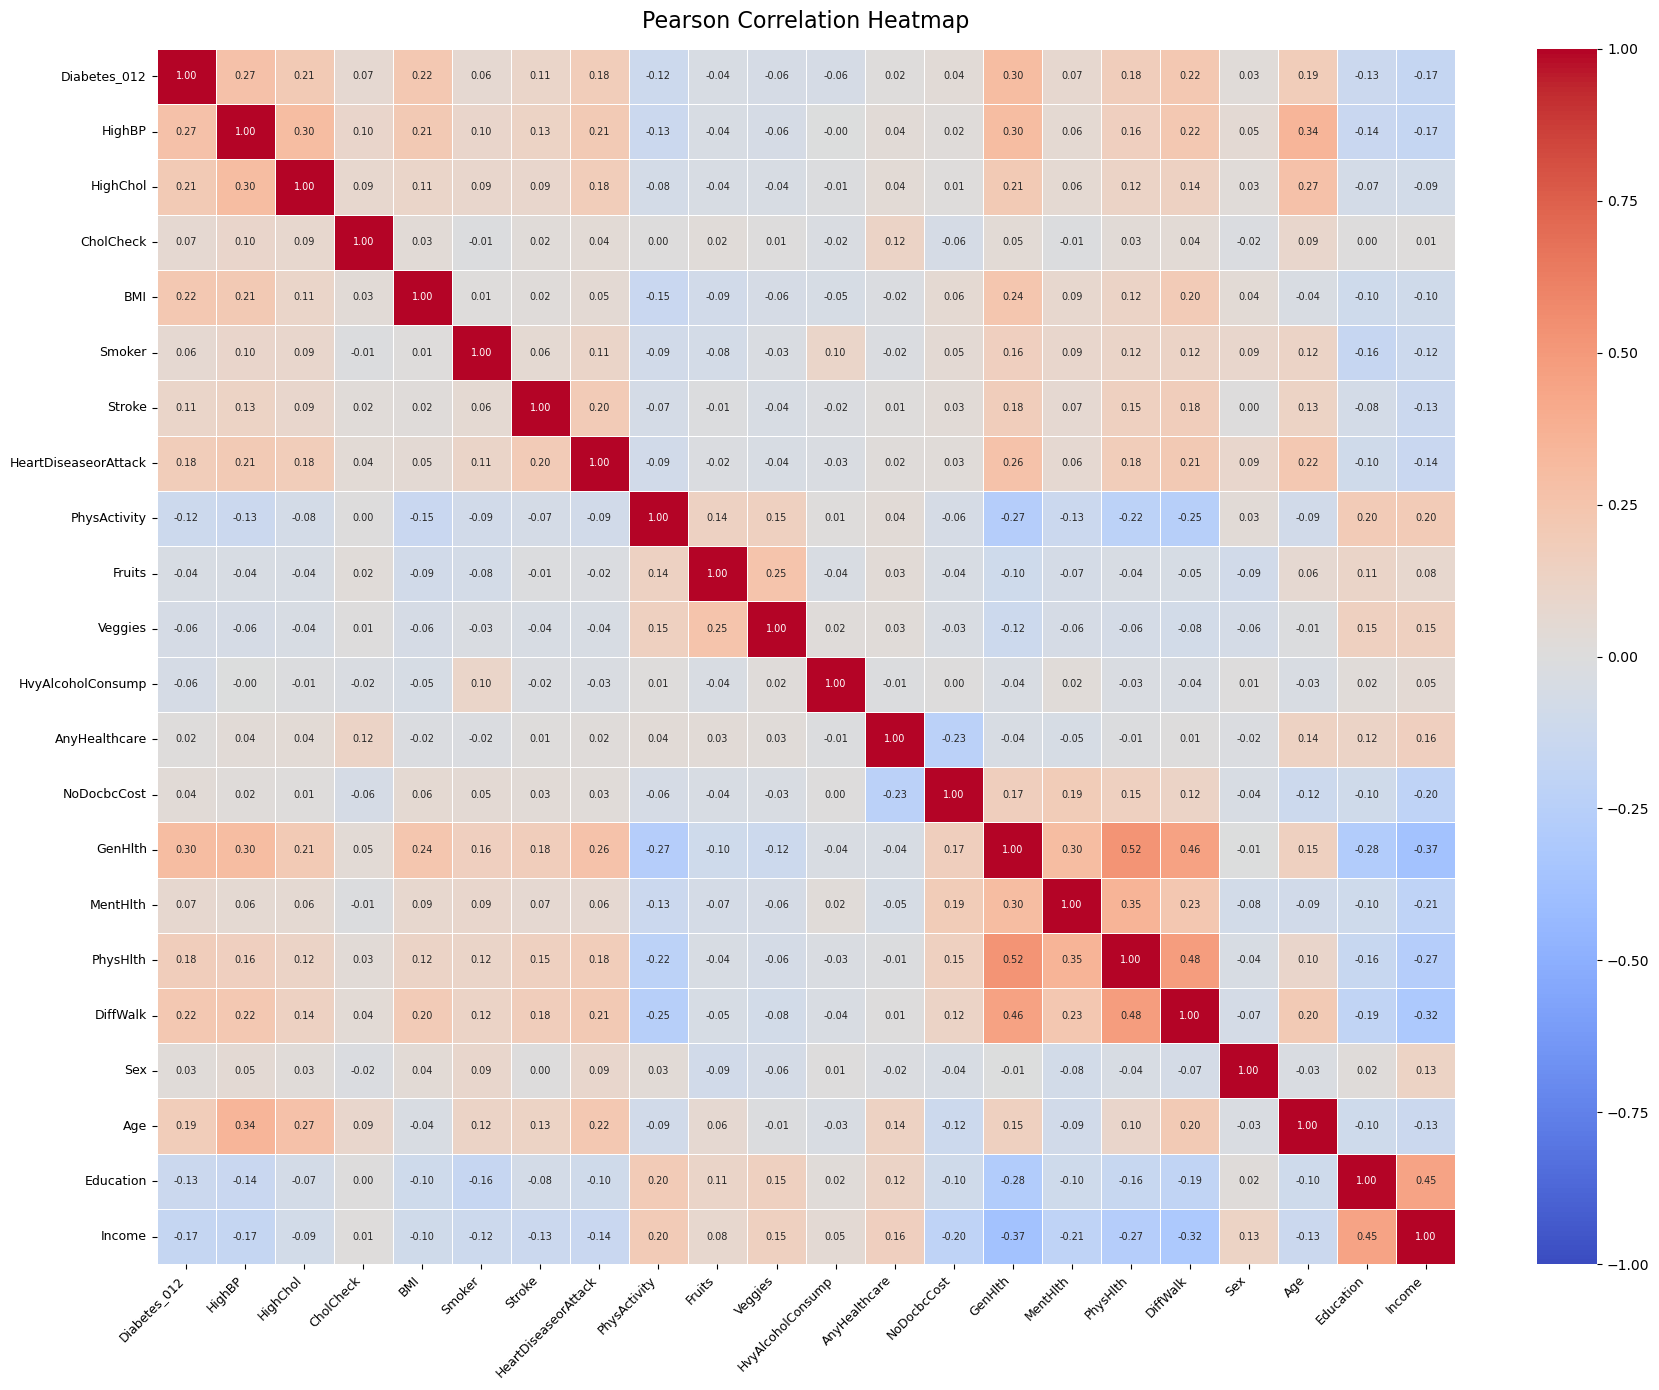

In [6]:
# Cek korelasi fitur dataset 
plt.figure(figsize=(18, 14))

cm = df.corr()

sns.heatmap(
    data=cm,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7}
)

plt.title('Pearson Correlation Heatmap', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Melihat hasil dari confusion matrix di atas, tidak terlalu banyak yang memiliki korelasi paling signifikan dengan target (```Diabetes_012```). Fitur yang memiliki korelasi positif adalah fitur ```HighBP```, ```HighChol```, ```BMI```, ```HeartDiseasorAttack```, ```GenHlth```, ```PhysHlth```, ```DiffWalk```, dan ```Age```.

Maka dari itu, sebagian besar dari dataset kemungkinan besar akan di lakukan feature engineering baik membuat kolom baru dari campuran fitur atau mereduksi beberapa fitur. Sebelum itu, langkah selanjutnya adalah untuk distribusi data antara yang memiliki diabetes dengan yang tidak.

In [7]:
# Cek jumlah kategori dari 
df.query('Diabetes_012 == 0').count()

Diabetes_012            213703
HighBP                  213703
HighChol                213703
CholCheck               213703
BMI                     213703
Smoker                  213703
Stroke                  213703
HeartDiseaseorAttack    213703
PhysActivity            213703
Fruits                  213703
Veggies                 213703
HvyAlcoholConsump       213703
AnyHealthcare           213703
NoDocbcCost             213703
GenHlth                 213703
MentHlth                213703
PhysHlth                213703
DiffWalk                213703
Sex                     213703
Age                     213703
Education               213703
Income                  213703
dtype: int64

In [8]:
df.query('Diabetes_012 == 1').count()

Diabetes_012            4631
HighBP                  4631
HighChol                4631
CholCheck               4631
BMI                     4631
Smoker                  4631
Stroke                  4631
HeartDiseaseorAttack    4631
PhysActivity            4631
Fruits                  4631
Veggies                 4631
HvyAlcoholConsump       4631
AnyHealthcare           4631
NoDocbcCost             4631
GenHlth                 4631
MentHlth                4631
PhysHlth                4631
DiffWalk                4631
Sex                     4631
Age                     4631
Education               4631
Income                  4631
dtype: int64

In [9]:
df.query('Diabetes_012 == 2').count()

Diabetes_012            35346
HighBP                  35346
HighChol                35346
CholCheck               35346
BMI                     35346
Smoker                  35346
Stroke                  35346
HeartDiseaseorAttack    35346
PhysActivity            35346
Fruits                  35346
Veggies                 35346
HvyAlcoholConsump       35346
AnyHealthcare           35346
NoDocbcCost             35346
GenHlth                 35346
MentHlth                35346
PhysHlth                35346
DiffWalk                35346
Sex                     35346
Age                     35346
Education               35346
Income                  35346
dtype: int64

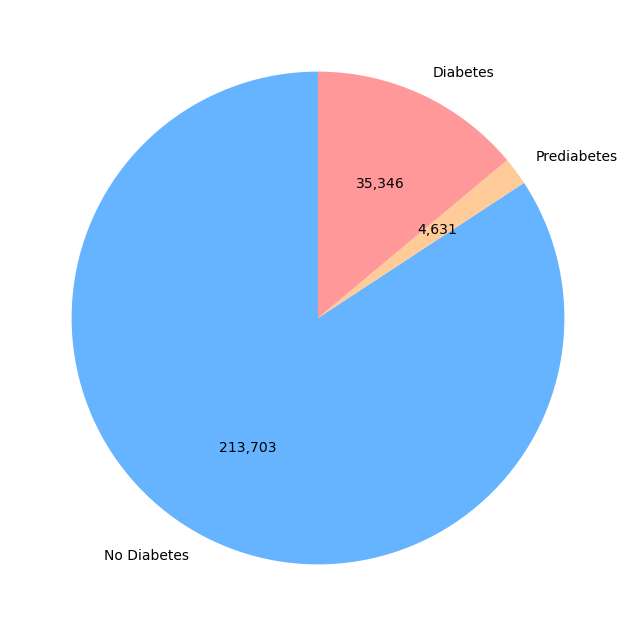

In [15]:
plt.figure(figsize=(12, 8))

counts = df['Diabetes_012'].value_counts().sort_index()

plt.pie(counts, labels=['No Diabetes', 'Prediabetes', 'Diabetes'], autopct=lambda p: f'{int(round(p * counts.sum() / 100)):,}', startangle=90, colors=['#66b3ff', '#ffcc99', '#ff9999'])
plt.show()

Hasil dari dataset ini menentukan bahwa:
1. Non Diabetik: 213703
2. Pre Diabetik: 4631
3. Diabetik: 35346

Melihat hasil distribusi data per kategori, data ini SANGAT imbalance. Maka dari itu perlu melakukan SMOTE untuk membuat data lebih balance. 

Hasil informasi ini menentukan terdapat beberapa hal yang dapat dilakukan, yaitu
1. Melihat hasil model dengan raw dataset,
2. Melihat hasil model dengan data yang sudah dilakukan feature engineering,
3. Melihat hasil model dengan data yang sudah dilakukan SMOTE.

#### Clean Dataset

Hal yang pertama dpat dilakukan adalah untuk mendeteksi nilai kosong dalam dataset. Jika terdapat nilai kosong, maka model akan susah untuk mempelajari pola dari dataset untuk mendeteksi diabetes.

In [16]:
# Cek null-value
df.isna().sum().sort_values(ascending=False)

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Kemudian ubah data kategorik menjadi label menggunakan encoding. Tetapi, hal itu tidak perlu dilakukan karena data yang tersedia sudah dalam bentuk numerik dalam float. Untuk membuat data lebih rapih secara visual, mari ubah dataset dalam bentuk float menjadi int (step ini bisa di skip, ini preference saja).

In [17]:
# Seperti pada hasil informasi sebelumnya, ubah semua data float menjadi int
df = df.astype('int64')

In [18]:
# Cek hasilnya lagi
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-null  int64


### Data Preprocessing

Model yang dibuat adalah untuk mendeteksi apakah model dapat mendeteksi antara orang yang diabetes dengan yang tidak diabetes, maka dari itu kategori prediabetik dapat dihilangkan.

In [19]:
# Hapus data yang memiliki kategori 1, yaitu prediabetik sesuai dengan label yang sudah dijelaskan
df = df[df['Diabetes_012'] != 1]

# Cek apakah sudah hilang atau belum
df.query('Diabetes_012 == 1').count()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [20]:
# Ubah label diabetik menjadi 1
df['Diabetes_012'] = df['Diabetes_012'].replace(2, 1)

In [21]:
# Cek unik target
df['Diabetes_012'].unique()

array([0, 1])

### Descriptive Statistics

Bagian ini mungkin agak tricky karena sudah dijelaskan sebelumnya yang merupakan numerik asli hanya ```BMI```, dan ```BMI``` semua orang itu variatif sehingga sedikit susah untuk mencari outliernya. Tidak hanya itu, ```MtnHlth``` dan ```PhysHlth``` prediksinya akan memiliki outlier yang sangat banyak juga. Walaupun begitu akan dilakukan statistika deskriptif.

In [22]:
# Panggil semua fitur yang merupakan numerik dan hitung statistika deskriptifnya
numerik = ['BMI', 'MentHlth', 'PhysHlth']

for col in numerik:
    print(f'Mean {col}: {df[col].mean()}')
    print(f'Median {col}: {df[col].median()}')
    print(f'Mode {col}: {df[col].mode()[0]}')
    print(f'Std {col}: {df[col].std()}')
    print(f'Q1 {col}: {df[col].quantile(0.25)}')
    print(f'Q3 {col}: {df[col].quantile(0.75)}')
    print(f'IQR {col}: {df[col].quantile(0.75) - df[col].quantile(0.25)}')
    print('')

Mean BMI: 28.3388128440588
Median BMI: 27.0
Mode BMI: 27
Std BMI: 6.594029956066632
Q1 BMI: 24.0
Q3 BMI: 31.0
IQR BMI: 7.0

Mean MentHlth: 3.159759725997695
Median MentHlth: 0.0
Mode MentHlth: 0
Std MentHlth: 7.3801201282418525
Q1 MentHlth: 0.0
Q3 MentHlth: 2.0
IQR MentHlth: 2.0

Mean PhysHlth: 4.202915892053371
Median PhysHlth: 0.0
Mode PhysHlth: 0
Std PhysHlth: 8.68103507993729
Q1 PhysHlth: 0.0
Q3 PhysHlth: 3.0
IQR PhysHlth: 3.0



In [23]:
# Bandingkan hasilnya dengan yang sama 
df[numerik].describe()

,BMI,MentHlth,PhysHlth
count,249049.000000,249049.00000,249049.000000
mean,28.338813,3.15976,4.202916
std,6.594030,7.38012,8.681035
min,12.000000,0.00000,0.000000
25%,24.000000,0.00000,0.000000
50%,27.000000,0.00000,0.000000
75%,31.000000,2.00000,3.000000
max,98.000000,30.00000,30.000000


Melihat hasil statistika deskriptif seperti ini, terdapat hal yang sangat tidak logis. BAGAIMANA SESEORANG BISA MEMILIKI BMI 98, seberapa besar persentase lemaknya. Setidaknya mental health dan physical health masih bisa diterima karena penyakit kronis untuk mental health atau pengalaman trauma untuk perhitungan mental health. Hal ini yang membuat dataset ini mungkin sulit untuk dilakukan preprocessing karena terdapat banyak data kategorik dan data numerik yang sangat tidak logis. Namun, perlu di cek distribusi data dari dataset ini terhadap data kategorik yang ada.

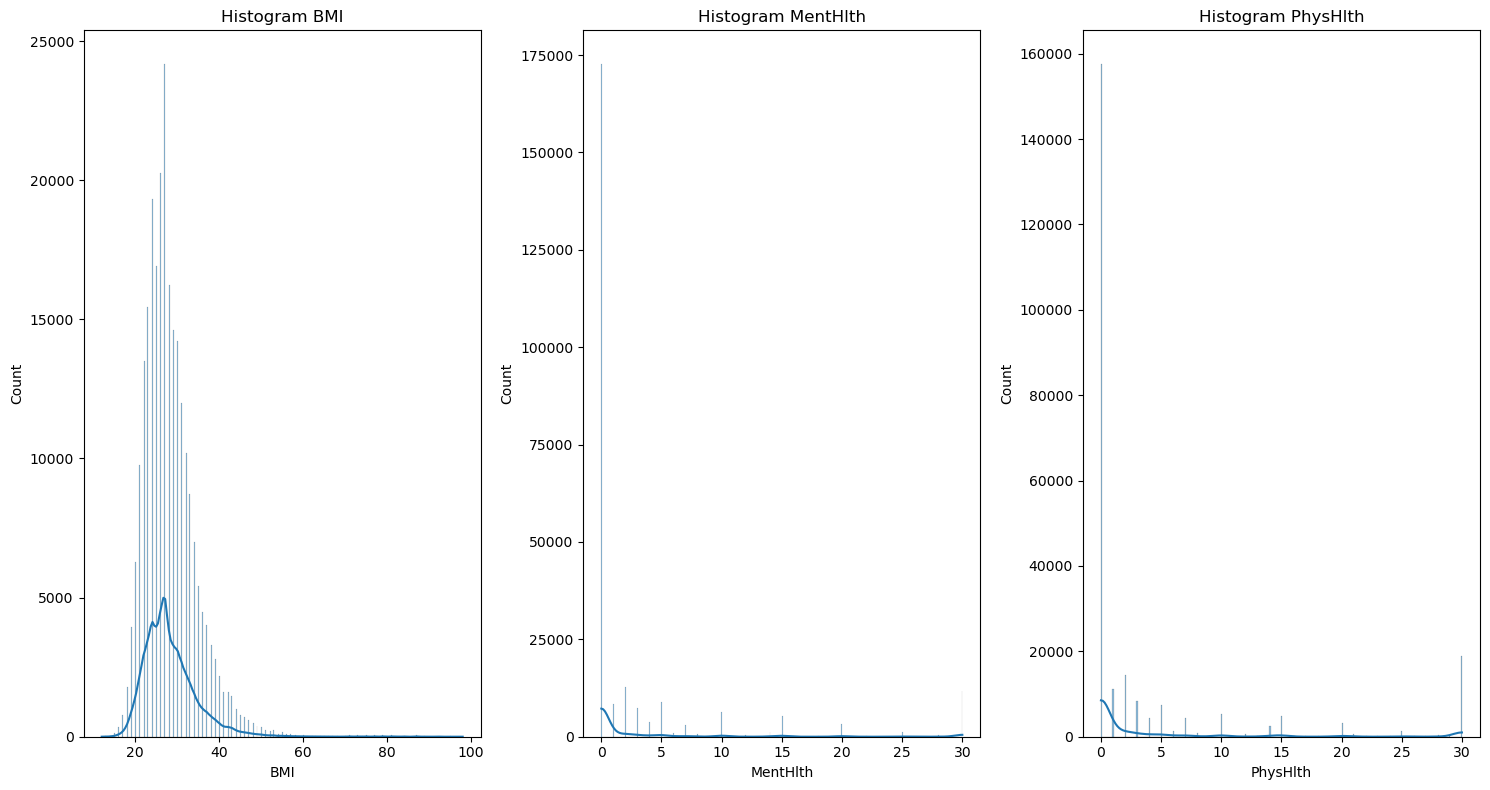

In [24]:
# Cek distribusi dari data numerik
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerik):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram {col}')
    
plt.tight_layout()
plt.show()

Secara visual, data terlihat sedikit skew dengan semuanya terlihat lebih right skewed. Namun begitu, data yang tersedia memang masuk akal, seperti tidak ada orang yang mengalami masalah fisik atau mental, serta memiliki BMI dengan range di bawah 50. Maka dari itu, harus dilihat outlier dari setiap data numerik.

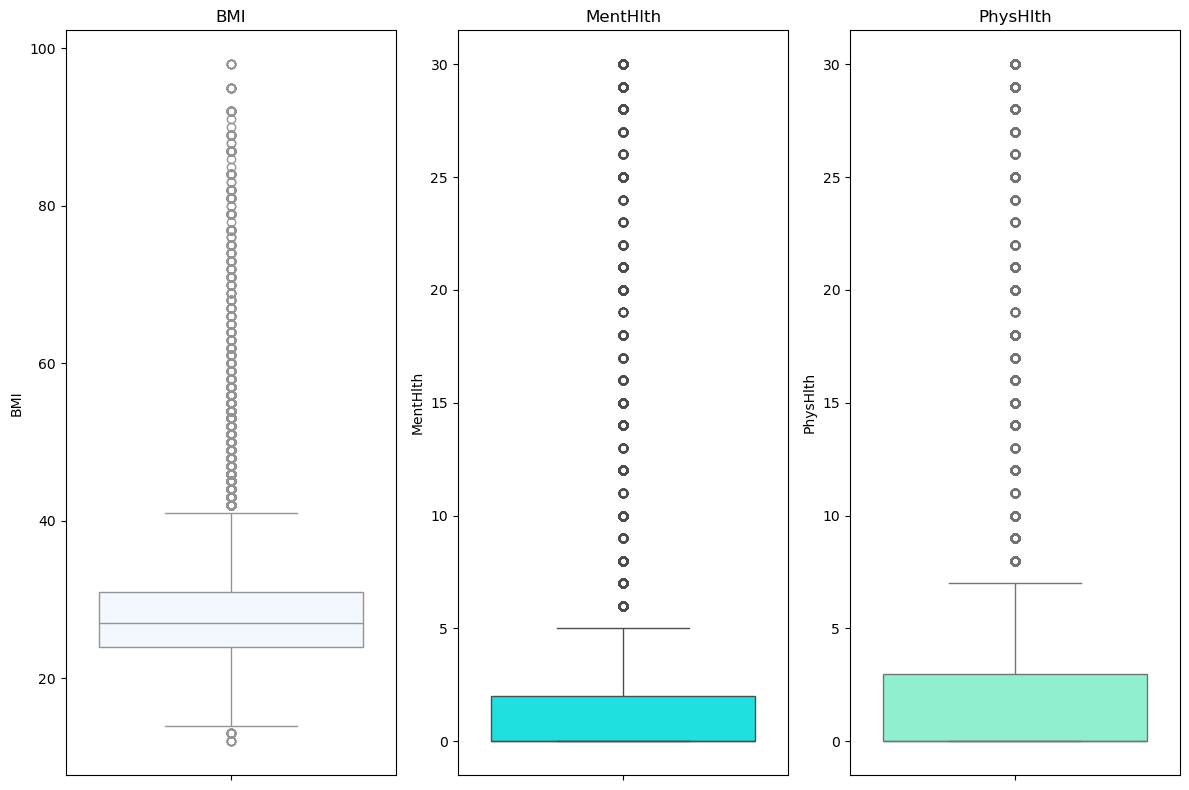

In [25]:
# Cek outlier dari hasil boxplot
fig, ax = plt.subplots(1, 3 , figsize=(12,8))
ax = ax.flatten()

color = ['aliceblue', 'aqua', 'aquamarine']

for i, col in enumerate(numerik):
    sns.boxplot(data=df, y=col, ax=ax[i], color=color[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

Seperti penjelasan sebelumnya, outlier yang ada disini cukup logis karena terdapat orang yang memiliki BMI tertentu dan hari-hari dimana mereka memiliki masalah mental dan fisik. Maka dari itu, tidak dapat dilakukan outlier handling.

### Inferential Statistics

Sebelum melakukan model training, akan dilaksanakan Chi-square test of independece untuk mengetahui hubungan setiap kolom dengan status diabetes yang bukan hanya kebetulan. Hal ini lebih baik digunakan daripada menggunakan pearson karena data dalam bentuk kategorik. Berikut merupakan hipotesis yang dikembangkan:
- H0: Fitur tidak berhubungan dengan diabetes
- H1: Fitur memiliki hubungan dengan diabetes

In [28]:
cat_col = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
]

chi2_results = []

for col in cat_col:
    ct = pd.crosstab(df[col], df['Diabetes_012'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        'Feature': col,
        'chi2': round(chi2, 2),
        'p-value': round(p, 6),
        'Signifikan (p < 0.05)': 'Signifikan' if p < 0.05 else 'Tidak Signifikan'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2', ascending=False)
chi2_df

,Feature,chi2,p-value,Signifikan (p < 0.05)
12,GenHlth,23404.41,0.0,Signifikan
0,HighBP,18062.62,0.0,Signifikan
13,DiffWalk,12493.57,0.0,Signifikan
1,HighChol,10535.04,0.0,Signifikan
15,Age,9034.34,0.0,Signifikan
5,HeartDiseaseorAttack,8180.57,0.0,Signifikan
17,Income,7267.25,0.0,Signifikan
16,Education,4201.24,0.0,Signifikan
6,PhysActivity,3647.18,0.0,Signifikan
4,Stroke,2902.81,0.0,Signifikan


Fitur dengan nilai Chi2 tinggi dan p-value < 0.05 menunjukkan hubungan yang signifikan secara statistik terhadap diabetes. Maka dari itu, hasil Chi-Squared test gagal menolak hipotesis H0. Fitur-fitur ini akan menjadi prioritas dalam proses feature engineering dan seleksi fitur selanjutnya. Namun, data akan tetap dicoba dalam bentuk raw untuk melihat perbedaan dan mendeteksi apakah data yang disebutkan akan terseleksi menggunakan model yang telah ditetapkan.

Kemudian, akan dilaksanakan Mann-Whiteney U test untuk menguji distribusi BMI, MentHlth, dan PhysHlth antara kelompok diabetik vs non-diabetik berbeda secara signifikan. Cocok karena distribusinya right-skewed (tidak normal). Berikut merupakan hipotesis yang dikembangkan:
- H0: Distribusi kedua kelompok (diabetik dan non-diabetik) identik
- H1: Terdapat perbedaan signifikan antar kelompok

In [29]:
mw_results = []

for col in numerik:
    group_diabetic = df[df['Diabetes_012'] == 1][col]
    group_nondiabetic = df[df['Diabetes_012'] == 0][col]

    stat, p = mannwhitneyu(
        group_diabetic,
        group_nondiabetic,
        alternative='two-sided'
    )

    mw_results.append({
        'Feature': col,
        'Median (Diabetik)':  round(group_diabetic.median(), 2),
        'Median (Non-Diabetik)': round(group_nondiabetic.median(), 2),
        'U-Statistic': round(stat, 2),
        'p-value': round(p, 6),
        'Signifikan (p < 0.05)': 'Signifikan' if p < 0.05 else 'Tidak Signifikan'
    })

mw_df = pd.DataFrame(mw_results)
mw_df

,Feature,Median (Diabetik),Median (Non-Diabetik),U-Statistic,p-value,Signifikan (p < 0.05)
0,BMI,31.0,27.0,5.221651e+09,0.0,Signifikan
1,MentHlth,0.0,0.0,3.988864e+09,0.0,Signifikan
2,PhysHlth,1.0,0.0,4.642582e+09,0.0,Signifikan


C:\Users\bobe\AppData\Local\Temp\ipykernel_6744\1413128675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bobe\AppData\Local\Temp\ipykernel_6744\1413128675.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Diabetik', 'Diabetik'])
C:\Users\bobe\AppData\Local\Temp\ipykernel_6744\1413128675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bobe\AppData\Local\Temp\ipykernel_6744\1413128675.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No

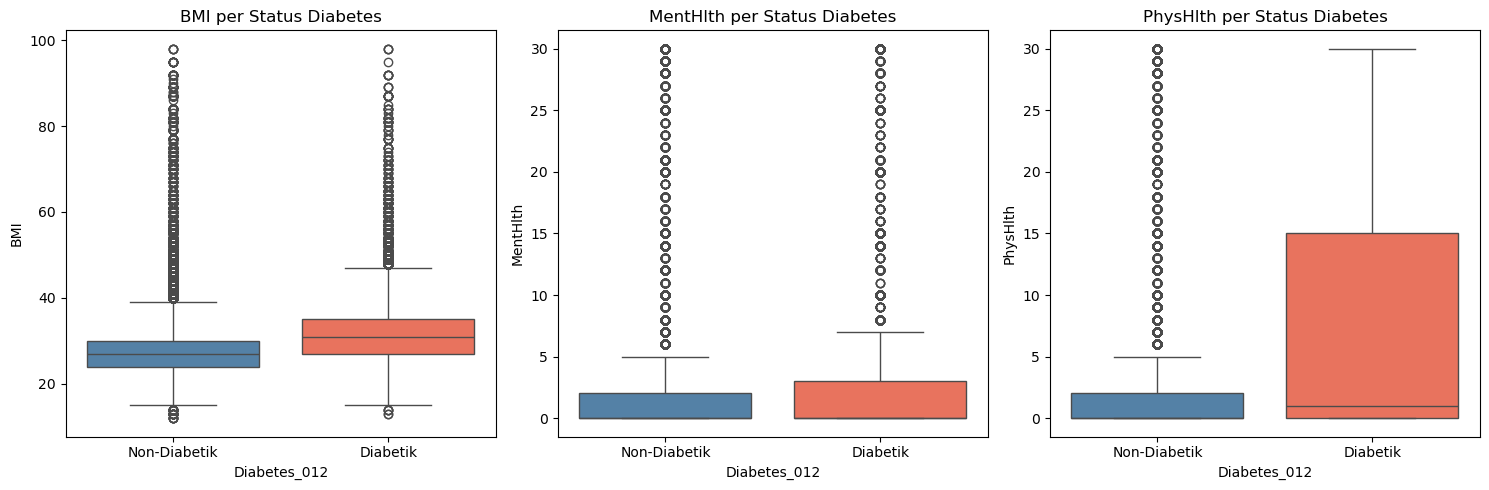

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerik):
    sns.boxplot(
        data=df, x='Diabetes_012', y=col,
        ax=axes[i],
        palette={'0': 'steelblue', '1': 'tomato'}
    )
    axes[i].set_title(f'{col} per Status Diabetes')
    axes[i].set_xticklabels(['Non-Diabetik', 'Diabetik'])

plt.tight_layout()
plt.show()

Sesuai dengan hasil yang telah didapatkan, semua kolom numerik memiliki nilai p-value < 0.05, maka dari itu, distribusi antara kelompok diabetik dan non-diabetik identik, sehingga hasil menolak hipotesis H0.

### Model Training with Raw Data

Seperti yang sudah ditetapkan di awal, tahap pertama untuk mendapatkan model dengan recall terbaik adalah dengan melakukan training dengan raw data. Namun, terdapat banyak sekali model untuk melakukan klaisifkasi yang tersedia. Maka dari itu, berikut merupakan list model yang digunakan:
1. Logistric Regression,
2. Decision Tree,
3. Random Forest,
4. Gradient Boosting,
5. Extra Trees,
6. K Nearest Neighbor, dan
7. XGBoost


Model-model ini dipilih dengan menyesuaikan dengan dataset yang tersedia karena memiliki fitur campuran (kategorik dan numerik) dengan jumlah kelas yang tidak seimbang.



Setelah menentukan model, langkah yang pertama dilakukan adalah untuk melakukan split dataset untuk fitur dan target. Kemudian, seluruh nama fitur dipisah dalam bentuk kategorik dan numerik. Selanjutnya melakukan training model untuk semua model yang telah disebutkan dan membandingkan hasil recall (sensitivity) dari setiap model. Metrik recall sangat umum digunakan dalam kasus deteksi kesehatan untuk meminimalisir kesalahan deteksi. Dalam proses training, model tidak dilakukan perubahan parameter sama sekali untuk membandingkan base model dapat beradaptasi dan menghasilkan hasil yang baik dengan raw data.

In [32]:
# Split Fitur dengan Target
X = df.drop(columns='Diabetes_012')
y = df['Diabetes_012']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tentukan Semua Kolom Kategori dan Numerik 
cat_col = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthCare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
num_col = numerik

In [ ]:
# Train dataset dengan model
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier()
}

results = {}

# Running model dengan looping untuk setiap model yang sudah ditentukan, lalu simpan hasilnya ke dalam dictionary results
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    
    recall = recall_score(y_test, y_pred, pos_label=1)

    
    results[name] = {
            'model': model,
            'recall': recall
        }

    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred))
    print('')

c:\Users\bobe\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     42741
           1       0.54      0.15      0.23      7069

    accuracy                           0.86     49810
   macro avg       0.71      0.56      0.58     49810
weighted avg       0.83      0.86      0.83     49810



=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     42741
           1       0.31      0.34      0.32      7069

    accuracy                           0.80     49810
   macro avg       0.60      0.61      0.60     49810
weighted avg       0.81      0.80      0.80     49810



=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     42741
           1       0.52      0.20      0.29      7069

    accuracy                           0.86     49810
   macro avg       0.70      0.58      0.60     498

In [34]:
# Simpan model terbaik berdasarkan Recall
best_model_name = max(results, key=lambda x: results[x]['recall'])
best_model = results[best_model_name]['model']
best_recall = results[best_model_name]['recall']

print(f'Best model based on recall: {best_model_name}')
print(f'Recall: {best_recall:.4f}')


Best model based on recall: Decision Tree
Recall: 0.3363


In [35]:
# Tampilkan recall setiap model dan di sortir dari recall terbaik ke terburuk
results_df = pd.DataFrame([
    {'Model (Recall)': name, 'Raw Data': info['recall']}
    for name, info in results.items()
]).sort_values(by='Raw Data', ascending=False).reset_index().drop(columns='index')

results_df


,Model (Recall),Raw Data
0,Decision Tree,0.336257
1,KNN,0.215023
2,Extra Trees,0.199745
3,XGB,0.198614
4,Random Forest,0.197765
5,Gradient Boosting,0.189843
6,Logistic Regression,0.148536


Dari hasil training raw data, Decision Tree memiliki recall terbaik sedangkan Logistic Regression (LR) memiliki hasil terburuk. Hal ini karena LR sangat menghafal data train yang diberikan sehingga tidak dapat melakukan generalisasi terhadap data test.

### Feature Engineering

Pada tahap ini akan dilakukan pembuatan fitur baru dan/atau mereduksi fitur, karena terdapat banyak fitur yang tidak memiliki korelasi yang cukup besar dengan target. Sebelum itu, mari kita lakukan feature importance untuk mengetahui fitur mana yang paling mempengaruhi menggunakan model dengan recall terbaik.
&nbsp;

Feature engineering pertama yang dapat dilakukan adalah melakukan penambahan fitur dari data yang sudah ada. Berikut merupakan beberapa fitur yang dapat ditambahkan:
```
1. CardioRisk = HighBP + HighChol + HeartDiseaseorAttack + Stroke
2. HealthyLifestyle = PhysActivity + Fruits + Veggies 
3. UnhealthyHabits = Smoker + HvyAlcoholConsump
4. Age_HighBP = Age * HighBP
```
&nbsp;

Penjelasan tambahan fitur:
1. Cardio Risk = Kondisi dimana seseorang memiliki tekanan darah tinggi, koleterol tinggi, memiliki penyakit jantung, dan pernah mengalami stroke.
2. Healthy Lifestyle = Fitur saat seseorang sering melakukan aktivitas fisik serta memakan serat
3. Unhealthy Habits = Fitur saat seseorang sering merokok dan meminum alkohol
4. Age_HighBP = Fitur yang mengetahui umur memiliki tekanan darah tinggi pada umur tersebut
&nbsp;

Cardio Risk dilakukan karena diabetes memiliki korelasi langsung dengan pennyakit Cardio Vascular Disease (CVD). Salah satu indikator seseorang memiliki CVD adalah dengan memiliki tekanan darah yang tinggi. Selain itu, kolesterol tinggi (terutama LDL) memiliki efek yang sama dengan CVD, sehingga memiliki korelasi langsung dengan diabetes. Maka dari itu, fitur tersebut dibuat dari gabungan antara tekanan darah tinggi, kolesterol tinggi, penyakit jantung, dan struk.

Healthy Lifestyle dan Unhealthy habits tentu saja mempengaruhi kondisi seseorang. Semakin baik lifestyle mereka, semakin baik juga kesehatan mereka dan chances untuk tidak memiliki diabetes. Semakin buruk habitnya, semakin jeleks juga kesehatan mereka.

Selain itu, salah satu yang membuat semakin tinggi tekanan darah seseorang adalah dengan umur. Sehingga Age_HighBP digunakan untuk mengukur apakah umur tersebut sudah memiliki tekanan darah atau belum.

Reference:
1. [Diabetes Mellitus and Cardiovascular Disease: Exploring Epidemiology, Pathophysiology, and Treatment Strategies](https://pmc.ncbi.nlm.nih.gov/articles/PMC11683709/)
2. [Association between serum LDL‐C concentrations and risk of diabetes: A prospective cohort study](https://pmc.ncbi.nlm.nih.gov/articles/PMC10590678/)
3. [High Blood Pressure and Older Adults](https://www.nia.nih.gov/health/high-blood-pressure/high-blood-pressure-and-older-adults)

In [36]:
# Buat fitur baru dan membuat copy dari dataset lama, agar tidak tercampur
df_added = df.copy()

df_added['CardioRisk'] = df_added['HighBP'] + df_added['HighChol'] + df_added['HeartDiseaseorAttack'] + df_added['Stroke']
df_added['HealthyLifestyle'] = df_added['PhysActivity'] + df_added['Fruits'] + df_added['Veggies']
df_added['UnhealthyHabits'] = df_added['Smoker'] + df_added['HvyAlcoholConsump']
df_added['Age_HighBP'] = df_added['Age'] * df_added['HighBP']

In [37]:
# Split lagi dataset dengan dataset baru
X_added = df_added.drop(columns='Diabetes_012')
y_added = df_added['Diabetes_012']

X_added_train, X_added_test, y_added_train, y_added_test = train_test_split(X_added, y_added, test_size=0.2, random_state=42, stratify=y_added)

### Model Training with Feature Engineering

In [ ]:
# Running model lagi paska penambahan fitur
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier()
}

results_added = {}

# Running model dengan looping untuk setiap model yang sudah ditentukan, lalu simpan hasilnya ke dalam dictionary results_added
for name, model in models.items():
    model.fit(X_added_train, y_added_train)
    y_added_pred = model.predict(X_added_test)

    
    recall = recall_score(y_added_test, y_added_pred, pos_label=1)

    
    results_added[name] = {
            'model': model,
            'recall': recall
        }

    print(f'\n=== {name} ===')
    print(classification_report(y_added_test, y_added_pred))
    print('')

c:\Users\bobe\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.98      0.92     42741
           1       0.51      0.16      0.24      7069

    accuracy                           0.86     49810
   macro avg       0.69      0.57      0.58     49810
weighted avg       0.82      0.86      0.83     49810



=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     42741
           1       0.31      0.33      0.32      7069

    accuracy                           0.80     49810
   macro avg       0.60      0.60      0.60     49810
weighted avg       0.81      0.80      0.80     49810



=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     42741
           1       0.50      0.20      0.29      7069

    accuracy                           0.86     49810
   macro avg       0.69      0.58      0.61     498

In [39]:
# Save model terbaik
best_model_name_added = max(results, key=lambda x: results[x]['recall'])
best_model_added = results[best_model_name_added]['model']
best_recall_added = results[best_model_name_added]['recall']

print(f'Best model based on recall: {best_model_name_added}')
print(f'Recall: {best_recall_added:.4f}')

Best model based on recall: Decision Tree
Recall: 0.3363


In [40]:
# Tambahkan hasil ke dataframe results
new_recalls = {name: info['recall'] for name, info in results_added.items()}

results_df['Added Feat'] = results_df['Model (Recall)'].map(new_recalls)

results_df

,Model (Recall),Raw Data,Added Feat
0,Decision Tree,0.336257,0.331589
1,KNN,0.215023,0.226623
2,Extra Trees,0.199745,0.214033
3,XGB,0.198614,0.193945
4,Random Forest,0.197765,0.203706
5,Gradient Boosting,0.189843,0.197341
6,Logistic Regression,0.148536,0.158014


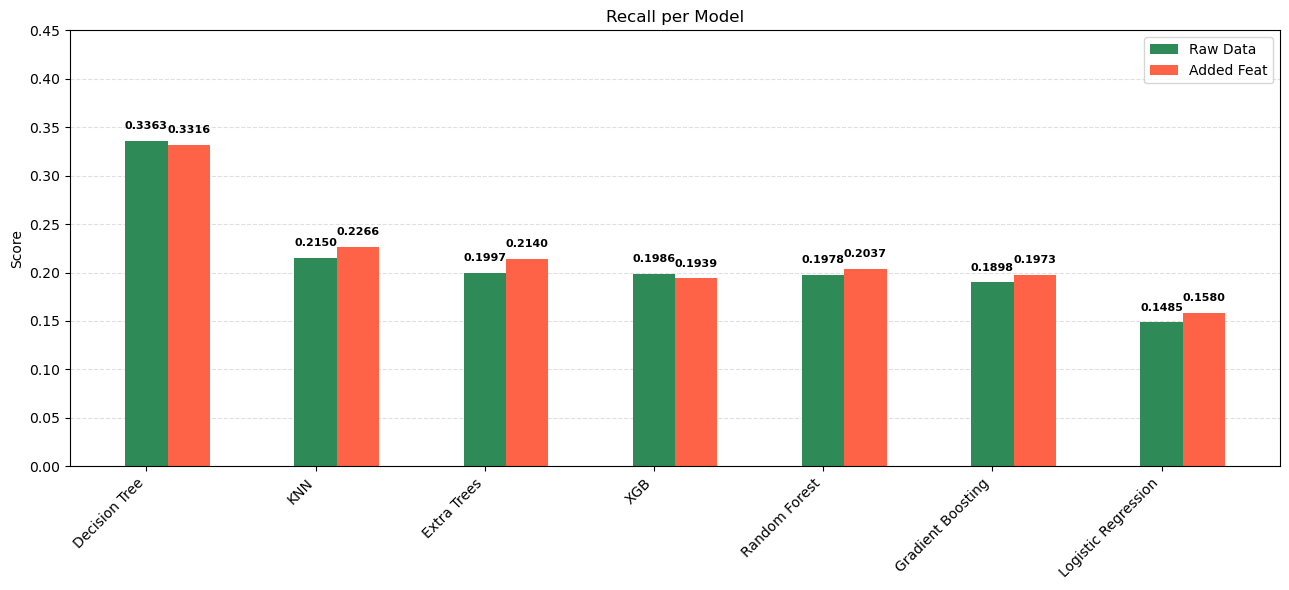

In [41]:
# Plot perbandingan recall menggunakan bar chart
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x, results_df['Raw Data'], width, label='Raw Data', color='seagreen')
ax.bar(x + width, results_df['Added Feat'], width, label='Added Feat',  color='tomato')

for bars, col in zip(
    [ax.containers[0], ax.containers[1]],
    ['Raw Data', 'Added Feat']
):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model (Recall)'], fontsize=10, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 0.45)
ax.set_title('Recall per Model')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Setelah menambahkan fitur, Sebagian besar model mengalami peningkatan recall kecuali XGB. Mari kita lanjutkan dengan Feature Selection untuk melihat perkembangan selanjutnya.

### Feature Selection

Setelah mendapatkan hasil recall setiap model dari penambahan fitur di atas, dilaksanakan fitur selection agar model dapat menggunakan fitur yang paling signifikan dalam mendeteksi diabetes. Sebelum itu, di cek korelasi menggunakan heatmap korelasi dari penmabhana fitur.

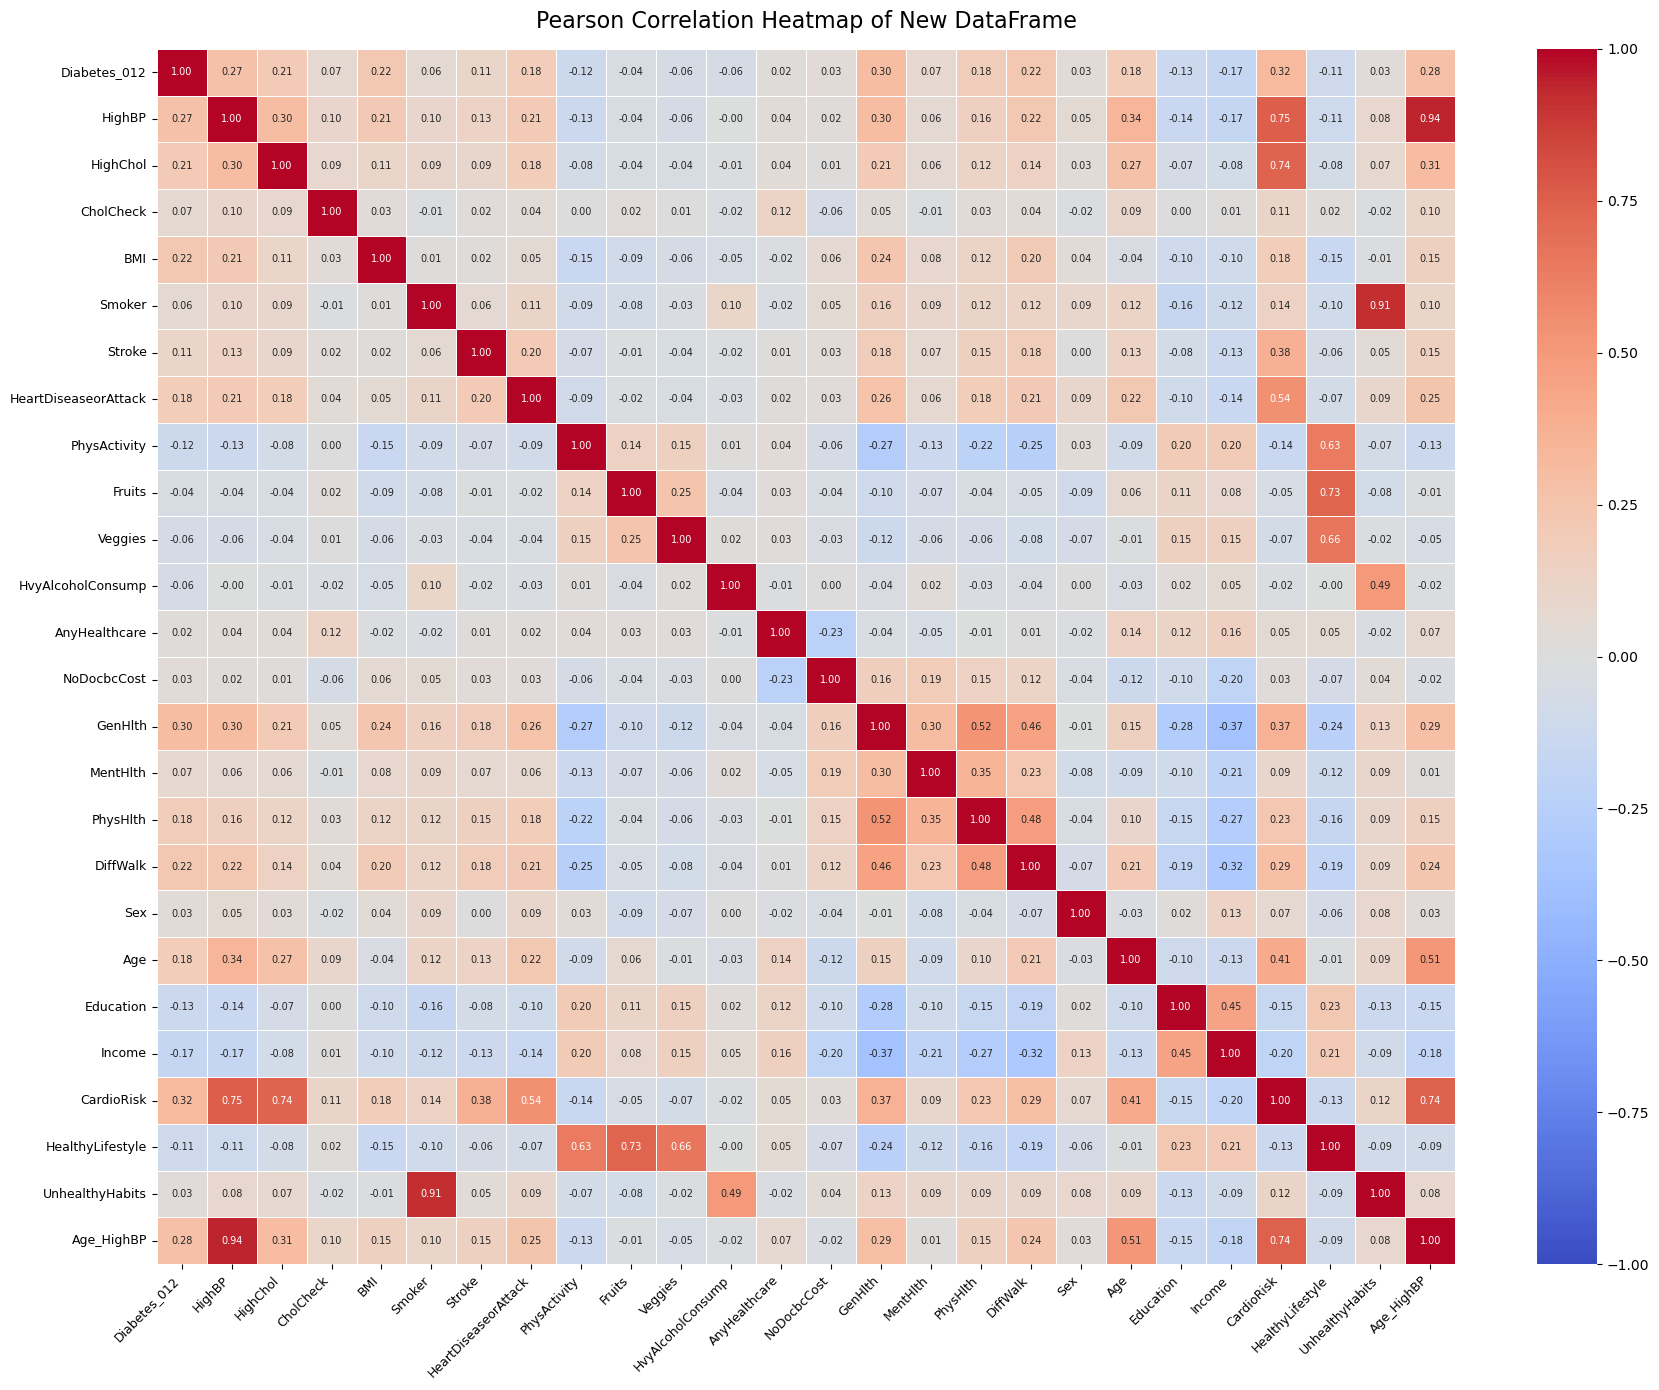

In [42]:
# Heatmap
plt.figure(figsize=(18, 14))

cm = df_added.corr()

sns.heatmap(
    data=cm,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7}
)

plt.title('Pearson Correlation Heatmap of New DataFrame', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Dapat dilihat bahwa target tidak memiliki perubahan korelasi yang signifikan antara fitur yang baru ditambahkan, tetapi memang ada yang memiliki relasi positif terhadap ```CardioRisk``` dan ```Age_HighBP```. Maka dari itu perlu dilakukan feature selection untuk menggunakan fitur yang paling mempengaruhi dalam pengembangan model.
&nbsp;

Untuk melakukan feature selection, perlu menggunakan model yang dapat mengetahui relasi non-linear. Model yang dapat digunakan untuk memilih adalah XGBoost.

In [43]:
selector = SelectFromModel(XGBClassifier(), threshold="median")

selector.fit(X_added_train, y_added_train)

X_train_selected = selector.transform(X_added_train)
X_test_selected = selector.transform(X_added_test)

selected_features = X_added.columns[selector.get_support()]
print('Features Kept')
for x in list(selected_features):
    print(f"Features kept: {x}")

Features Kept
Features kept: HighChol
Features kept: CholCheck
Features kept: BMI
Features kept: HvyAlcoholConsump
Features kept: AnyHealthcare
Features kept: GenHlth
Features kept: DiffWalk
Features kept: Sex
Features kept: Age
Features kept: Education
Features kept: Income
Features kept: CardioRisk
Features kept: Age_HighBP


In [44]:
df_selected = df_added[['Diabetes_012'] + list(selected_features)]

df_selected

,Diabetes_012,HighChol,CholCheck,BMI,HvyAlcoholConsump,AnyHealthcare,GenHlth,DiffWalk,Sex,Age,Education,Income,CardioRisk,Age_HighBP
0,0,1,1,40,0,1,5,1,0,9,4,3,2,9
1,0,0,0,25,0,0,3,0,0,7,6,1,0,0
2,0,1,1,28,0,1,5,1,0,9,4,8,2,9
3,0,0,1,27,0,1,2,0,0,11,3,6,1,11
4,0,1,1,24,0,1,2,0,0,11,5,4,2,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0,1,1,45,0,1,3,0,1,5,6,7,2,5
253676,1,1,1,18,0,1,4,1,0,11,2,4,2,11
253677,0,0,1,28,0,1,1,0,0,2,5,2,0,0
253678,0,0,1,23,0,1,3,0,1,7,5,1,1,7


Setelah melihat hasil pemilihan fitur, dapat dilihat bahwa fitur yang dipilih adalah fitur yang masih memiliki relasi positif dengan target. Namun, tidak semua fitur diambil karena ada ```threshodl='median'``` yang membatasi semua fitur terambil di atas median value dari list relasi positif. Setelah mendapatkan fitur tersebut data dimasukkan dipisahkan lagi antara target dengan fitur untuk digunakan dalam pelaksanaan model training.

### Model Training with Feature Selection

Hasil seleksi fitur dilaksanakan dengan cara yang sama seperti dua tahap sebelumnya dengan memisahkan target dan fitur, kemudian menjalankan semua model dengan data yang baru, dan membandingkan hasil dari semua tahap.

In [45]:
# Pisahkan lagi datanya
X_selected = df_selected.drop(columns='Diabetes_012')
y_selected = df_selected['Diabetes_012']

X_selected_train, X_selected_test, y_selected_train, y_selected_test = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42, stratify=y_selected)

In [ ]:
# Running model lagi paska 
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier()
}

results_added = {}

# Running model dengan looping untuk setiap model yang sudah ditentukan, lalu simpan hasilnya ke dalam dictionary results_added
for name, model in models.items():
    model.fit(X_selected_train, y_selected_train)
    y_selected_pred = model.predict(X_selected_test)

    
    recall = recall_score(y_selected_test, y_selected_pred, pos_label=1)

    
    results_added[name] = {
            'model': model,
            'recall': recall
        }

    print(f'\n=== {name} ===')
    print(classification_report(y_selected_test, y_selected_pred))
    print('')

c:\Users\bobe\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.98      0.92     42741
           1       0.54      0.17      0.26      7069

    accuracy                           0.86     49810
   macro avg       0.71      0.57      0.59     49810
weighted avg       0.83      0.86      0.83     49810



=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     42741
           1       0.34      0.30      0.32      7069

    accuracy                           0.82     49810
   macro avg       0.61      0.60      0.61     49810
weighted avg       0.81      0.82      0.81     49810



=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     42741
           1       0.41      0.25      0.31      7069

    accuracy                           0.84     49810
   macro avg       0.65      0.59      0.61     498

In [47]:
# Save model terbaik
best_model_name_added = max(results, key=lambda x: results[x]['recall'])
best_model_added = results[best_model_name_added]['model']
best_recall_added = results[best_model_name_added]['recall']

print(f'Best model based on recall: {best_model_name_added}')
print(f'Recall: {best_recall_added:.4f}')

Best model based on recall: Decision Tree
Recall: 0.3363


In [48]:
# Tambahkan hasil ke dataframe results
new_recalls = {name: info['recall'] for name, info in results_added.items()}

results_df['Feat Importance'] = results_df['Model (Recall)'].map(new_recalls)

results_df

,Model (Recall),Raw Data,Added Feat,Feat Importance
0,Decision Tree,0.336257,0.331589,0.295940
1,KNN,0.215023,0.226623,0.231716
2,Extra Trees,0.199745,0.214033,0.248691
3,XGB,0.198614,0.193945,0.185458
4,Random Forest,0.197765,0.203706,0.245579
5,Gradient Boosting,0.189843,0.197341,0.196775
6,Logistic Regression,0.148536,0.158014,0.168765


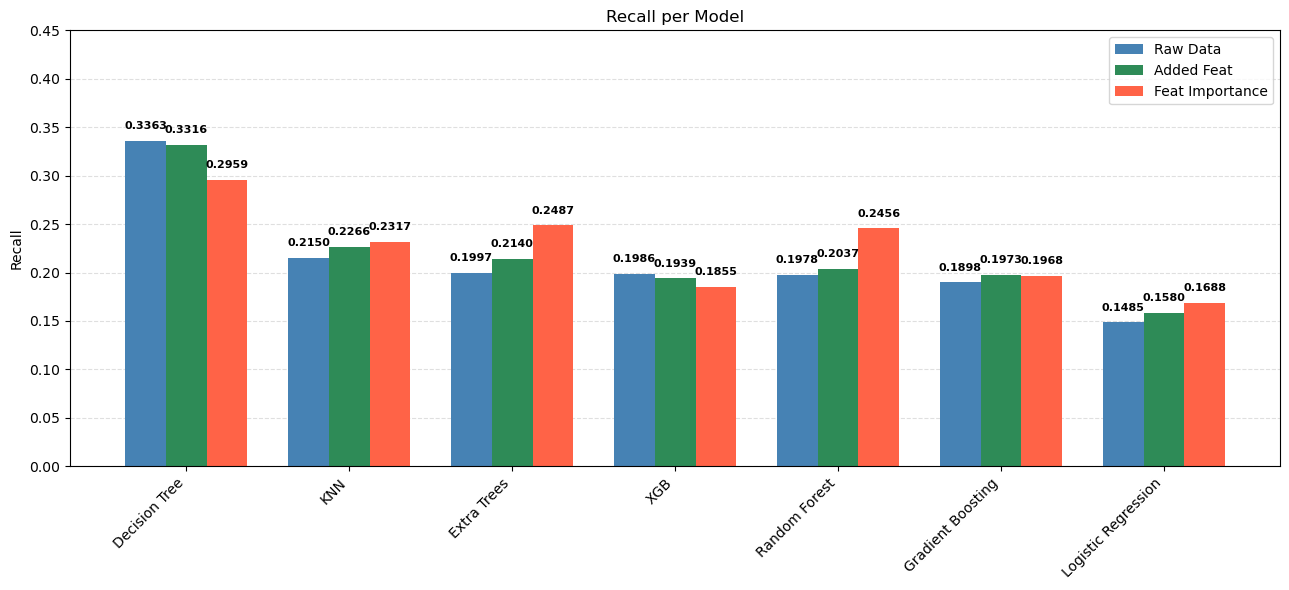

In [ ]:
# Plot perbandingan recall menggunakan bar chart
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width, results_df['Raw Data'], width, label='Raw Data', color='steelblue')
ax.bar(x, results_df['Added Feat'], width, label='Added Feat', color='seagreen')
ax.bar(x + width, results_df['Feat Importance'], width, label='Feat Importance', color='tomato')

for bars, col in zip(
    [ax.containers[0], ax.containers[1], ax.containers[2]],
    ['Raw Data', 'Added Feat', 'Feat Importance']
):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model (Recall)'], fontsize=10, rotation=45, ha='right')
ax.set_ylabel('Recall')
ax.set_ylim(0, 0.45)
ax.set_title('Recall per Model')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Melihat hasil recall setelah melaksanakan feature importance dapat ditentukan bahwa sebagian besar model mengalami increase dan mengalami decrease dalam recall. Penurunan dan kenaikan ini sangat signifikan dibanding hasil recall dari raw data maupun penambahan fitur. Hal ini mungkin terjadi karena imbalance data yang sempat disebutkan sebelumnya. Maka dari itu, langkah selanjutnya adalah untuk membuat data lebih balance menggunakan SMOTE.

### SMOTE

Synthetic Minority Over Sampling Technique (SMOTE), merupakan teknik untuk membantu target yang kurang dapat balance dengan target yang lebih. Metode ini akan digunakan untuk data Diabetik.

In [50]:
# Lakukan SMOTE pada training data
smote = SMOTE(random_state=42)

X_sm_train, y_sm_train = smote.fit_resample(X_selected_train, y_selected_train)

print("Before SMOTE:", y_selected_train.value_counts())
print("After SMOTE:", y_sm_train.value_counts())

Before SMOTE: Diabetes_012
0    170962
1     28277
Name: count, dtype: int64
After SMOTE: Diabetes_012
0    170962
1    170962
Name: count, dtype: int64


### Model Training with SMOTE

Lakukan model training setelah melaksanakan SMOTE dengan semua model.

In [ ]:
# Running model lagi paska 
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier()
}

results_added = {}

# Running model dengan looping untuk setiap model yang sudah ditentukan, lalu simpan hasilnya ke dalam dictionary results_added
for name, model in models.items():
    model.fit(X_sm_train, y_sm_train)
    y_sm_pred = model.predict(X_selected_test)

    
    recall = recall_score(y_selected_test, y_sm_pred, pos_label=1)

    
    results_added[name] = {
            'model': model,
            'recall': recall
        }

    print(f'\n=== {name} ===')
    print(classification_report(y_selected_test, y_sm_pred))
    print('')

c:\Users\bobe\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     42741
           1       0.32      0.77      0.45      7069

    accuracy                           0.73     49810
   macro avg       0.63      0.75      0.63     49810
weighted avg       0.86      0.73      0.77     49810



=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     42741
           1       0.27      0.44      0.34      7069

    accuracy                           0.75     49810
   macro avg       0.58      0.62      0.59     49810
weighted avg       0.81      0.75      0.77     49810



=== Random Forest ===
              precision    recall  f1-score   support

           0       0.91      0.81      0.86     42741
           1       0.30      0.49      0.38      7069

    accuracy                           0.77     49810
   macro avg       0.60      0.65      0.62     498

In [52]:
# Save model terbaik
best_model_name_added = max(results, key=lambda x: results[x]['recall'])
best_model_added = results[best_model_name_added]['model']
best_recall_added = results[best_model_name_added]['recall']

print(f'Best model based on recall: {best_model_name_added}')
print(f'Recall: {best_recall_added:.4f}')

Best model based on recall: Decision Tree
Recall: 0.3363


In [53]:
# Tambahkan hasil ke dataframe results
new_recalls = {name: info['recall'] for name, info in results_added.items()}

results_df['SMOTE'] = results_df['Model (Recall)'].map(new_recalls)

results_df

,Model (Recall),Raw Data,Added Feat,Feat Importance,SMOTE
0,Decision Tree,0.336257,0.331589,0.295940,0.443627
1,KNN,0.215023,0.226623,0.231716,0.491159
2,Extra Trees,0.199745,0.214033,0.248691,0.450276
3,XGB,0.198614,0.193945,0.185458,0.761352
4,Random Forest,0.197765,0.203706,0.245579,0.494978
5,Gradient Boosting,0.189843,0.197341,0.196775,0.792757
6,Logistic Regression,0.148536,0.158014,0.168765,0.766162


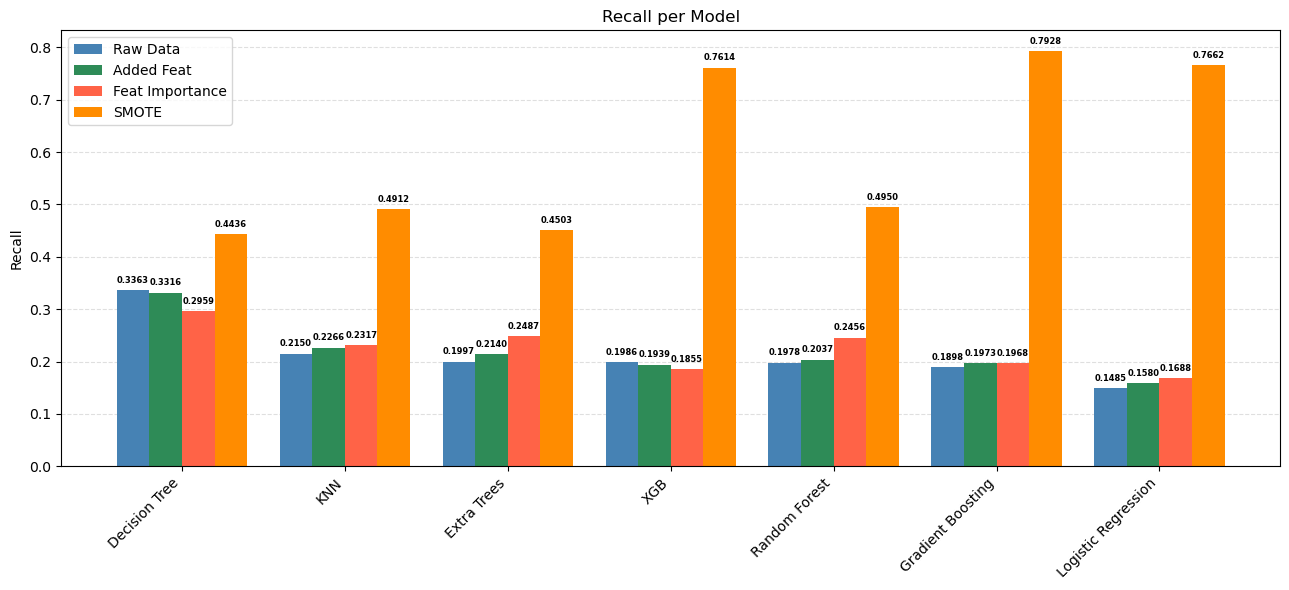

In [ ]:
# Plot perbandingan recall menggunakan bar chart
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - 1.5*width, results_df['Raw Data'], width, label='Raw Data', color='steelblue')
ax.bar(x - 0.5*width, results_df['Added Feat'], width, label='Added Feat', color='seagreen')
ax.bar(x + 0.5*width, results_df['Feat Importance'], width, label='Feat Importance', color='tomato')
ax.bar(x + 1.5*width, results_df['SMOTE'], width, label='SMOTE', color='darkorange')


for bars, col in zip(
    [ax.containers[0], ax.containers[1], ax.containers[2], ax.containers[3]],
    ['Raw Data', 'Added Feat', 'Feat Importance', 'SMOTE']
):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.4f}', ha='center', va='bottom', fontsize=6, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model (Recall)'], fontsize=10, rotation=45, ha='right')
ax.set_ylabel('Recall')
ax.set_title('Recall per Model')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('mini_project_2_FaradayBarrFatahillah.png')
plt.show()

Dapat dilihat, sebagian besar model setelah dilakukan SMOTE memiliki recall yang lebih besar. Maka dari itu, model yang digunakan untuk mendeteksi diabetes ada Gradient Boosting dengan recall sebesar 79.28%

### Hyperparameter Tuning

Langkah ini dilakukan untuk dapat meningkatkan recall dari model sehingga meningkatkan performa dan sensitivitas model terhadap penyakit diabetes. Cara melakukan hal ini adalah dengan menjalankan beberapa set dari parameter yang sudah ditentukan dengan GridSearchCV. Setelah mendapatkan hasil terbaik, akan diambil model dengan parameter terbaik kemudian dilakukan lagi hingga recall dari hasil ```clasification_report``` menurun.


Pelaksanaan tuning akan bertahap dimana hal yang pertama dilakukan adalah sebagai berikut
1. Tuning ```learning_rate```,
2. Tuning ```n_estimators```,
3. Tuning ```max_depth```


Hal ini dilaksanakan secara bertahap karena memiliki pengaruh yang sangat besar terhadap performa model.

In [67]:
grid_param1 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

In [68]:
model_gb = GradientBoostingClassifier(random_state=42)

grid_search1 = GridSearchCV(
    model_gb,
    param_grid=grid_param1,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [69]:
grid_search1.fit(X_sm_train, y_sm_train)

print("Best Params:", grid_search1.best_params_)
print("Best CV Recall:", grid_search1.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV Recall: 0.8097821299586793


In [70]:
grid_search1.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [71]:
best_gb1 = grid_search1.best_estimator_

y_best_pred1 = best_gb1.predict(X_selected_test)

print(classification_report(y_selected_test, y_best_pred1))
print("Recall:", recall_score(y_selected_test, y_best_pred1, pos_label=1))

              precision    recall  f1-score   support

           0       0.95      0.72      0.82     42741
           1       0.31      0.76      0.44      7069

    accuracy                           0.73     49810
   macro avg       0.63      0.74      0.63     49810
weighted avg       0.86      0.73      0.77     49810

Recall: 0.757391427358891


<Figure size 1000x600 with 0 Axes>

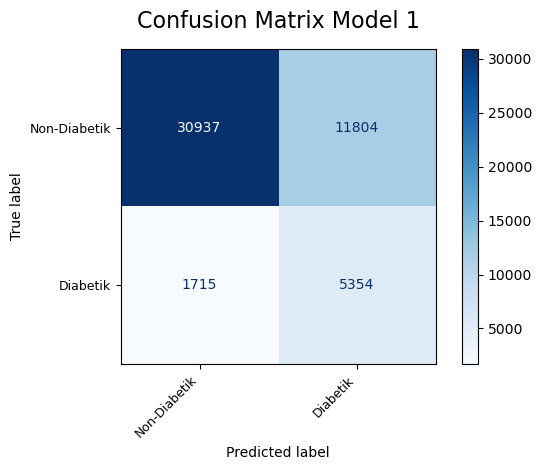

In [77]:
plt.figure(figsize=(10, 6))

cm = confusion_matrix(y_selected_test, y_best_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetik', 'Diabetik'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix Model 1', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Seusai dengan rencana sebelumnya, learning rate akan diubah sebagai langkah pertama hyperparameter tuning. Melihat hasil classification report, model memiliki 75.7% recall pada kelas diabetik. Selain itu, hasil dari confusion matrix menandakan masih banyak kelas yang salah terklasifikasi sebagai diabetik, sekitar 1715 data. Maka dari itu, langkah selanjutnya adalah mengubah learning rate menjadi ```[0.2, 0.3, 0.4]``` untuk melihat perbedaan recall.

In [78]:
grid_param2 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

In [79]:
model_gb = GradientBoostingClassifier(random_state=42)

grid_search2 = GridSearchCV(
    model_gb,
    param_grid=grid_param2,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [80]:
grid_search2.fit(X_sm_train, y_sm_train)

print("Best Params:", grid_search2.best_params_)
print("Best CV Recall:", grid_search2.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'learning_rate': 0.4, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best CV Recall: 0.8142041716636144


In [81]:
grid_search2.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.4
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [82]:
best_gb2 = grid_search2.best_estimator_

y_best_pred2 = best_gb2.predict(X_selected_test)

print(classification_report(y_selected_test, y_best_pred2))
print("Recall:", recall_score(y_selected_test, y_best_pred2, pos_label=1))

              precision    recall  f1-score   support

           0       0.94      0.73      0.82     42741
           1       0.31      0.74      0.44      7069

    accuracy                           0.73     49810
   macro avg       0.63      0.74      0.63     49810
weighted avg       0.86      0.73      0.77     49810

Recall: 0.7439524685245438


<Figure size 1000x600 with 0 Axes>

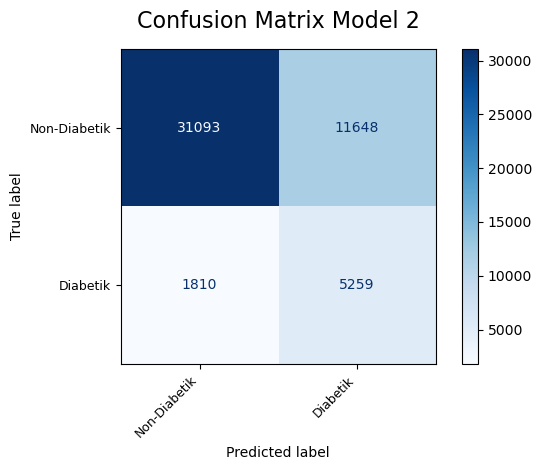

In [83]:
plt.figure(figsize=(10, 6))

cm = confusion_matrix(y_selected_test, y_best_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetik', 'Diabetik'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix Model 2', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Melihat hasil dari training ini, ternyata meningkatkan learning rate menurunkan hasil recall. Maka dari itu, sesuai dengan rencana yang sudah ditentukan di awal, training akan menetapkan learning rate pada range training pertama dan meningkatkan ```n_estimators```.

In [84]:
grid_param3 = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

In [85]:
model_gb = GradientBoostingClassifier(random_state=42)

grid_search3 = GridSearchCV(
    model_gb,
    param_grid=grid_param3,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [86]:
grid_search3.fit(X_sm_train, y_sm_train)

print("Best Params:", grid_search3.best_params_)
print("Best CV Recall:", grid_search3.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best CV Recall: 0.8131747059662606


In [89]:
grid_search3.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [87]:
best_gb3 = grid_search3.best_estimator_

y_best_pred3 = best_gb3.predict(X_selected_test)

print(classification_report(y_selected_test, y_best_pred3))
print("Recall:", recall_score(y_selected_test, y_best_pred3, pos_label=1))

              precision    recall  f1-score   support

           0       0.94      0.73      0.82     42741
           1       0.31      0.74      0.44      7069

    accuracy                           0.73     49810
   macro avg       0.63      0.74      0.63     49810
weighted avg       0.85      0.73      0.77     49810

Recall: 0.7414061394822464


<Figure size 1000x600 with 0 Axes>

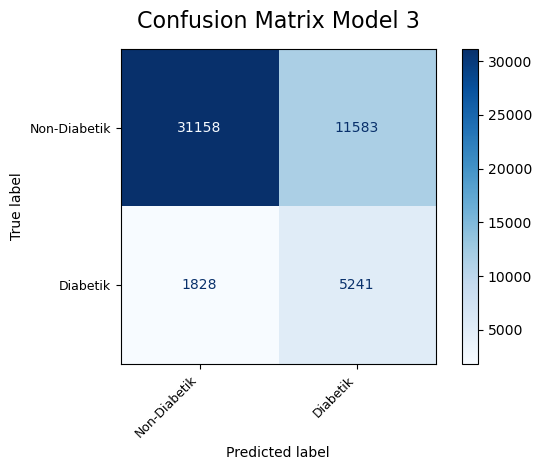

In [88]:
plt.figure(figsize=(10, 6))

cm = confusion_matrix(y_selected_test, y_best_pred3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetik', 'Diabetik'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix Model 3', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Ternyata saat diubah ```n_estimators```, hasil recall memburuk, maka dari itu, menggunakan parameter sebelumnya dan mengubah ```max_depth```. Parameter ini dirubah menjadi 

In [90]:
grid_param4 = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [5, 6, 7],
    'subsample': [0.8, 1.0]
}

In [91]:
model_gb = GradientBoostingClassifier(random_state=42)

grid_search4 = GridSearchCV(
    model_gb,
    param_grid=grid_param4,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [92]:
grid_search4.fit(X_sm_train, y_sm_train)

print("Best Params:", grid_search4.best_params_)
print("Best CV Recall:", grid_search4.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Recall: 0.8321672299062763


In [93]:
grid_search4.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",7
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [94]:
best_gb4 = grid_search4.best_estimator_

y_best_pred4 = best_gb4.predict(X_selected_test)

print(classification_report(y_selected_test, y_best_pred4))
print("Recall:", recall_score(y_selected_test, y_best_pred4, pos_label=1))

              precision    recall  f1-score   support

           0       0.94      0.75      0.83     42741
           1       0.31      0.69      0.43      7069

    accuracy                           0.74     49810
   macro avg       0.62      0.72      0.63     49810
weighted avg       0.85      0.74      0.77     49810

Recall: 0.6945819776488895


<Figure size 1000x600 with 0 Axes>

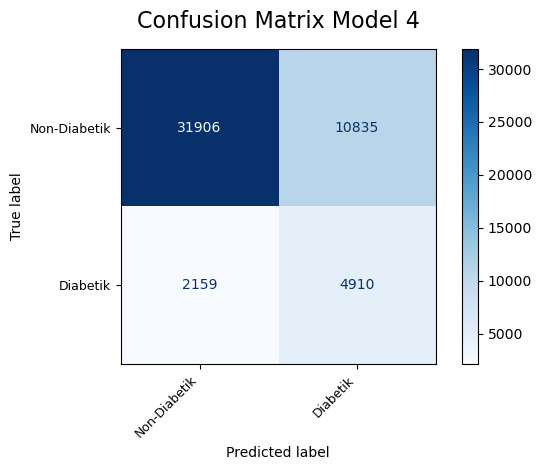

In [95]:
plt.figure(figsize=(10, 6))

cm = confusion_matrix(y_selected_test, y_best_pred4)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetik', 'Diabetik'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix Model 4', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Hasil recall yang di dapatkan ternyata sangat jauh, maka dari itu, model yang dipakai adalah yang memiliki parameter sebagai berikut
```Python
grid_param1 = {
    'n_estimators': 300,
    'learning_rate': 0.1,
    'max_depth': 5,
    'subsample': 0.8
}
```

&nbsp;

Maka dari setting parameter ini menjadi model yang paling baik untuk mendeteksi diabetes. Namun, sebelum menetapkan hasil yang tetap, perlu di lakukan Bootstrap confidence interval untuk nilai recall, sehingga bisa menyimpulkan performa model yang dikembangkan merupakan yang terbaik. Semakin sempit interval yang dihasilkan, semakin konsisten model.

In [96]:
N_BOOTSTRAP = 1000
bootstrap_recalls = []

for i in range(N_BOOTSTRAP):
    X_bs, y_bs = resample(
        X_selected_test,
        y_selected_test,
        random_state=i
    )
    y_pred_bs = best_gb1.predict(X_bs)
    recall_bs = recall_score(y_bs, y_pred_bs, pos_label=1)
    bootstrap_recalls.append(recall_bs)

lower = np.percentile(bootstrap_recalls, 2.5)
upper = np.percentile(bootstrap_recalls, 97.5)
mean_recall = np.mean(bootstrap_recalls)

print(f"Mean Recall: {mean_recall:.4f}")
print(f"95% CI Recall: [{lower:.4f}, {upper:.4f}]")
print(f"Interval Width: {upper - lower:.4f}")

Mean Recall: 0.7574
95% CI Recall: [0.7480, 0.7673]
Interval Width: 0.0193


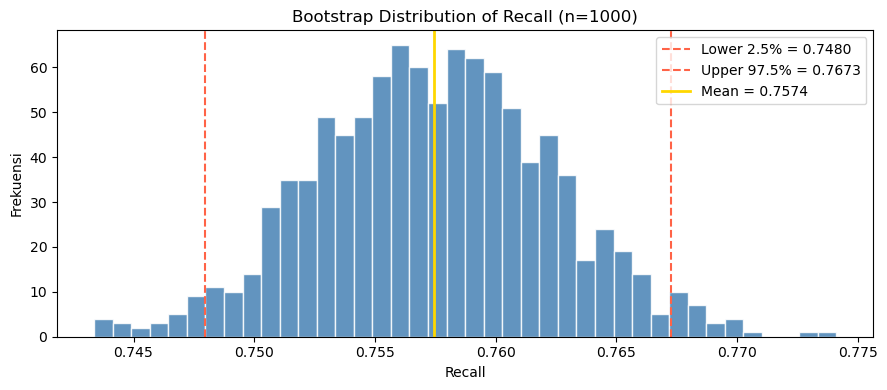

In [97]:
plt.figure(figsize=(9, 4))
plt.hist(bootstrap_recalls, bins=40, color='steelblue',edgecolor='white', alpha=0.85)
plt.axvline(lower, color='tomato', linestyle='--',label=f'Lower 2.5% = {lower:.4f}')
plt.axvline(upper, color='tomato', linestyle='--', label=f'Upper 97.5% = {upper:.4f}')
plt.axvline(mean_recall, color='gold', linestyle='-', linewidth=2, label=f'Mean = {mean_recall:.4f}')
plt.xlabel('Recall')
plt.ylabel('Frekuensi')
plt.title('Bootstrap Distribution of Recall (n=1000)')
plt.legend()
plt.tight_layout()
plt.show()

### Kesimpulan

Penelitian ini bertujuan untuk mengembangkan model prediksi diabetes menggunakan dataset BFRSS dengan 22 fitur kesehatan dan gaya hidup. Setelah melihat hasil pengembangan model untuk deteksi diabetes ini, dapat disimpulkan bahwa model berhasil dikembangkan dengan meraih recall sebesar 75.74%. Selain itu berikut merupakan beberapa temuan utama yang diperoleh:
1. Hasil analisis Chi-Squared Test menunjukkan bahwa seluruh fitur kategorik memiliki hubungan yang signifikan secara statistik terhadap status diabetes, dengan fitur ```GenHlth```, ```HighBP```, dan ```DiffWalk``` menjadi fitur paling dominan.
2. Penanganan Imbalanced Data pada dataset sangat membantu performa model dengan model sebelum dilakukan SMOTE memiliki recall rata-rata di bawah 35% dan mengalami peningkatan menjadi di atas 75%.
3. Gradient Boosting menjadi model terbaik berdasarkan recall tertinggi pada kelas diabetik. Model ini unggul karena kemampuannya membangun ensemble secara sekuensial sehingga lebih adaptif terhadap pola minoritas setelah SMOTE diterapkan dan Hyperparameter tuning.

### Rekomendasi dan Saran

Beberapa rekomendasi dan saran yang dapat diterapkan adalah:
1. Meningkatkan recall model karena masih terdapat banyak pasien yang tidak terdeteksi,
2. Menggunakan model yang lebih kompleks atau melakukan feature engineering yang relevan dengan dataset.